## DP2 ELAIS-S1 SkyMap coverage

The LSST–VISTA fusion processing for DP2 uses the `lsst_cells_v2` SkyMap. Here, I determine exactly which DP2 tracts and patches cover the ELAIS-S1 deep drilling field.

This notebook:

- defines the nominal ELAIS-S1 DP2 region;
- finds all `lsst_cells_v2` tracts and patches that geometrically overlap the field;
- identifies the subset of patches for which DP2 `deep_coadd` data actually exist;
- reports the available bands for every tract/patch;
- visualizes the tract and patch coverage; and
- writes a tract/patch manifest that can be reused when selecting the Monster reference-catalog shards.

The nominal DP2 ELAIS-S1 field is represented here by a circle centred at RA = 9.5 deg, Dec = -44.0 deg, with radius 1.0 deg.


### 1. Import packages

In [1]:
from collections import defaultdict
from pathlib import Path

import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

import lsst.geom as geom
import lsst.sphgeom as sphgeom
from lsst.daf.butler import Butler


### 2. Initialize the DP2 Butler and define ELAIS-S1

In [2]:
butler = Butler("dp2", collections="dp2")

skymap_name = "lsst_cells_v2"

ra_center = 9.5
dec_center = -44.0
radius = 1.0

elais_region = sphgeom.Region.from_ivoa_pos(
    f"CIRCLE {ra_center} {dec_center} {radius}"
)

print(f"SkyMap: {skymap_name}")
print(
    f"ELAIS-S1: RA={ra_center:.2f} deg, "
    f"Dec={dec_center:.2f} deg, radius={radius:.2f} deg"
)


SkyMap: lsst_cells_v2
ELAIS-S1: RA=9.50 deg, Dec=-44.00 deg, radius=1.00 deg


### 3. Find all SkyMap tracts and patches overlapping ELAIS-S1

The `tract` and `patch` dimension tables describe the geometry of the SkyMap. These queries therefore identify every tract and patch whose region intersects the adopted ELAIS-S1 circle, independently of whether a DP2 coadd dataset is present in that patch.


In [3]:
tract_records = list(
    butler.query_dimension_records(
        "tract",
        where="skymap = :skymap AND tract.region OVERLAPS :region",
        bind={"skymap": skymap_name, "region": elais_region},
        limit=None,
    )
)

patch_records = list(
    butler.query_dimension_records(
        "patch",
        where="skymap = :skymap AND patch.region OVERLAPS :region",
        bind={"skymap": skymap_name, "region": elais_region},
        limit=None,
    )
)

geometric_tracts = sorted(
    {record.dataId["tract"] for record in tract_records}
)

geometric_patches = sorted(
    {
        (record.dataId["tract"], record.dataId["patch"])
        for record in patch_records
    }
)

print("Geometrically overlapping tracts:")
print(geometric_tracts)
print(f"Number of tracts: {len(geometric_tracts)}")
print(f"Number of patches: {len(geometric_patches)}")


Geometrically overlapping tracts:
[2703, 2704, 2876, 2877, 3053, 3054]
Number of tracts: 6
Number of patches: 183


### 4. Find patches with DP2 deep coadds

A SkyMap patch can geometrically overlap ELAIS-S1 even if no DP2 image dataset exists there. For the fusion processing, the more useful footprint is therefore the set of tract/patch combinations that have `deep_coadd` data in the DP2 collection.

The query is performed without selecting a band. The available bands are collected for every tract/patch combination.


In [4]:
deep_coadd_refs = list(
    butler.query_datasets(
        "deep_coadd",
        where=(
            "skymap = :skymap AND "
            "patch.region OVERLAPS :region"
        ),
        bind={
            "skymap": skymap_name,
            "region": elais_region,
        },
        limit=None,
    )
)

bands_by_patch = defaultdict(set)

for ref in deep_coadd_refs:
    tract_id = int(ref.dataId["tract"])
    patch_id = int(ref.dataId["patch"])
    band = str(ref.dataId["band"])
    bands_by_patch[(tract_id, patch_id)].add(band)

dp2_patches = sorted(bands_by_patch)
dp2_tracts = sorted({tract for tract, patch in dp2_patches})

print("Tracts with DP2 deep_coadd data:")
print(dp2_tracts)
print(f"Number of tracts: {len(dp2_tracts)}")
print(f"Number of tract/patch combinations: {len(dp2_patches)}")
print(f"Number of deep_coadd datasets: {len(deep_coadd_refs)}")


Tracts with DP2 deep_coadd data:
[2703, 2704, 2876, 2877, 3053, 3054]
Number of tracts: 6
Number of tract/patch combinations: 183
Number of deep_coadd datasets: 1098


### 5. Compare geometric and populated coverage

This comparison shows whether any patches that intersect the nominal ELAIS-S1 region are present only as SkyMap geometry and do not contain a DP2 `deep_coadd`.


In [5]:
geometric_patch_set = set(geometric_patches)
dp2_patch_set = set(dp2_patches)

without_deep_coadd = sorted(geometric_patch_set - dp2_patch_set)

print(
    "Geometric patches without a DP2 deep_coadd:",
    len(without_deep_coadd),
)

if without_deep_coadd:
    print(without_deep_coadd)


Geometric patches without a DP2 deep_coadd: 0


### 6. Report tract, patch, and band coverage

The table below is also useful for deciding which part of the DP2 footprint should be processed with VISTA. A patch is marked as complete when all six LSST bands (`ugrizy`) are available.


In [6]:
lsst_bands = {"u", "g", "r", "i", "z", "y"}

for tract_id in dp2_tracts:
    print(f"\nTract {tract_id}")
    tract_patches = [
        patch_id
        for tract, patch_id in dp2_patches
        if tract == tract_id
    ]

    for patch_id in tract_patches:
        bands = sorted(bands_by_patch[(tract_id, patch_id)])
        complete = set(bands) >= lsst_bands
        print(
            f"  patch {patch_id:2d}: "
            f"{','.join(bands):11s} "
            f"complete_ugrizy={complete}"
        )



Tract 2703
  patch 70: g,i,r,u,y,z complete_ugrizy=True
  patch 71: g,i,r,u,y,z complete_ugrizy=True
  patch 72: g,i,r,u,y,z complete_ugrizy=True
  patch 73: g,i,r,u,y,z complete_ugrizy=True
  patch 80: g,i,r,u,y,z complete_ugrizy=True
  patch 81: g,i,r,u,y,z complete_ugrizy=True
  patch 82: g,i,r,u,y,z complete_ugrizy=True
  patch 83: g,i,r,u,y,z complete_ugrizy=True
  patch 84: g,i,r,u,y,z complete_ugrizy=True
  patch 90: g,i,r,u,y,z complete_ugrizy=True
  patch 91: g,i,r,u,y,z complete_ugrizy=True
  patch 92: g,i,r,u,y,z complete_ugrizy=True
  patch 93: g,i,r,u,y,z complete_ugrizy=True
  patch 94: g,i,r,u,y,z complete_ugrizy=True
  patch 95: g,i,r,u,y,z complete_ugrizy=True

Tract 2704
  patch 75: g,i,r,u,y,z complete_ugrizy=True
  patch 76: g,i,r,u,y,z complete_ugrizy=True
  patch 77: g,i,r,u,y,z complete_ugrizy=True
  patch 78: g,i,r,u,y,z complete_ugrizy=True
  patch 79: g,i,r,u,y,z complete_ugrizy=True
  patch 84: g,i,r,u,y,z complete_ugrizy=True
  patch 85: g,i,r,u,y,z complet

### 7. Save the tract/patch manifest

The manifest records the DP2 tract/patch footprint and the bands available in each patch. The later Monster-coverage notebook can use this file directly instead of selecting complete tracts.


In [7]:
output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)

manifest_path = output_dir / "DP2_ELAIS1_tract_patch_coverage.csv"

with manifest_path.open("w", newline="") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        ["tract", "patch", "bands", "n_bands", "complete_ugrizy"]
    )

    for tract_id, patch_id in dp2_patches:
        bands = sorted(bands_by_patch[(tract_id, patch_id)])
        writer.writerow(
            [
                tract_id,
                patch_id,
                "".join(bands),
                len(bands),
                set(bands) >= lsst_bands,
            ]
        )

print(f"Wrote: {manifest_path}")


Wrote: data/DP2_ELAIS1_tract_patch_coverage.csv


### 8. Plot the DP2 tract and patch coverage

The figure shows:

- the nominal 1-degree ELAIS-S1 boundary;
- the boundaries of patches with DP2 `deep_coadd` data; and
- the tract boundaries and tract identifiers.

Right ascension increases to the left, following the usual astronomical convention.


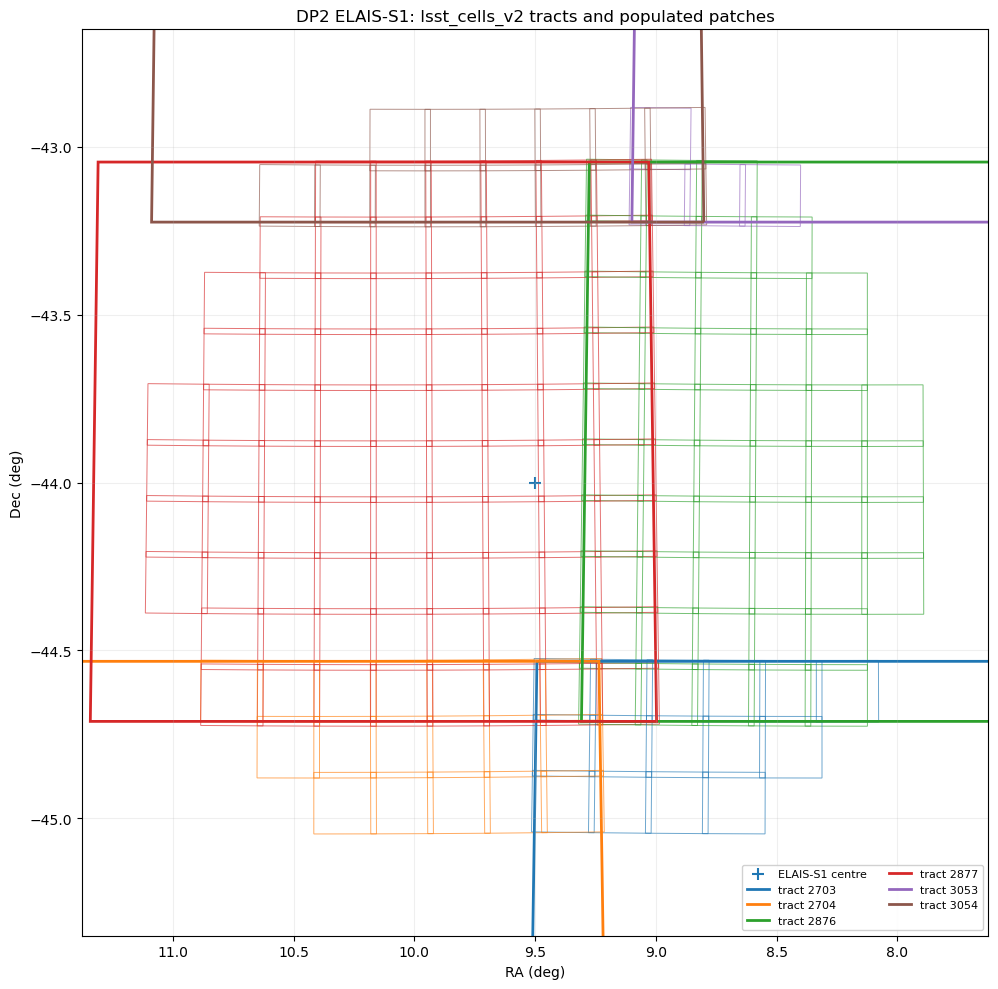

Saved: data/figures/DP2_ELAIS1_skymap_coverage.png
Saved: data/figures/DP2_ELAIS1_skymap_coverage.pdf


In [8]:
def region_vertices_deg(region):
    vertices = []
    for vertex in region.getVertices():
        point = geom.SpherePoint(vertex)
        vertices.append(
            [
                point.getRa().asDegrees(),
                point.getDec().asDegrees(),
            ]
        )
    return np.asarray(vertices)


# Retain only patch-dimension records that correspond to actual DP2 coadds.
dp2_patch_records = [
    record
    for record in patch_records
    if (
        int(record.dataId["tract"]),
        int(record.dataId["patch"]),
    )
    in dp2_patch_set
]

# Use Matplotlib's default color cycle, assigning one color per tract.
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
tract_colors = {
    tract_id: default_colors[index % len(default_colors)]
    for index, tract_id in enumerate(dp2_tracts)
}

fig, ax = plt.subplots(figsize=(11, 10))

# Plot populated DP2 patch boundaries.
for record in dp2_patch_records:
    tract_id = int(record.dataId["tract"])
    vertices = region_vertices_deg(record.region)

    polygon = Polygon(
        vertices,
        closed=True,
        fill=False,
        linewidth=0.7,
        edgecolor=tract_colors[tract_id],
        alpha=0.65,
    )
    ax.add_patch(polygon)

# Plot tract boundaries and tract IDs.
for record in tract_records:
    tract_id = int(record.dataId["tract"])

    if tract_id not in dp2_tracts:
        continue

    vertices = region_vertices_deg(record.region)
    polygon = Polygon(
        vertices,
        closed=True,
        fill=False,
        linewidth=2.0,
        edgecolor=tract_colors[tract_id],
    )
    ax.add_patch(polygon)


ax.scatter(
    [ra_center],
    [dec_center],
    marker="+",
    s=80,
    label="ELAIS-S1 centre",
)

# Add one legend entry per tract.
for tract_id in dp2_tracts:
    ax.plot(
        [],
        [],
        linewidth=2.0,
        color=tract_colors[tract_id],
        label=f"tract {tract_id}",
    )

ra_half_width = 1.35 * radius / np.cos(np.deg2rad(dec_center))
dec_half_width = 1.35 * radius

ax.set_xlim(
    ra_center + ra_half_width,
    ra_center - ra_half_width,
)
ax.set_ylim(
    dec_center - dec_half_width,
    dec_center + dec_half_width,
)

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("DP2 ELAIS-S1: lsst_cells_v2 tracts and populated patches")
ax.set_aspect(
    1.0 / np.cos(np.deg2rad(dec_center)),
    adjustable="box",
)
ax.legend(
    loc="lower right",
    fontsize=8,
    framealpha=0.9,
    ncol=2,
)
ax.grid(alpha=0.2)

plt.tight_layout()

figure_dir = Path("data/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

png_path = figure_dir / "DP2_ELAIS1_skymap_coverage.png"
pdf_path = figure_dir / "DP2_ELAIS1_skymap_coverage.pdf"

fig.savefig(png_path, dpi=200, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")



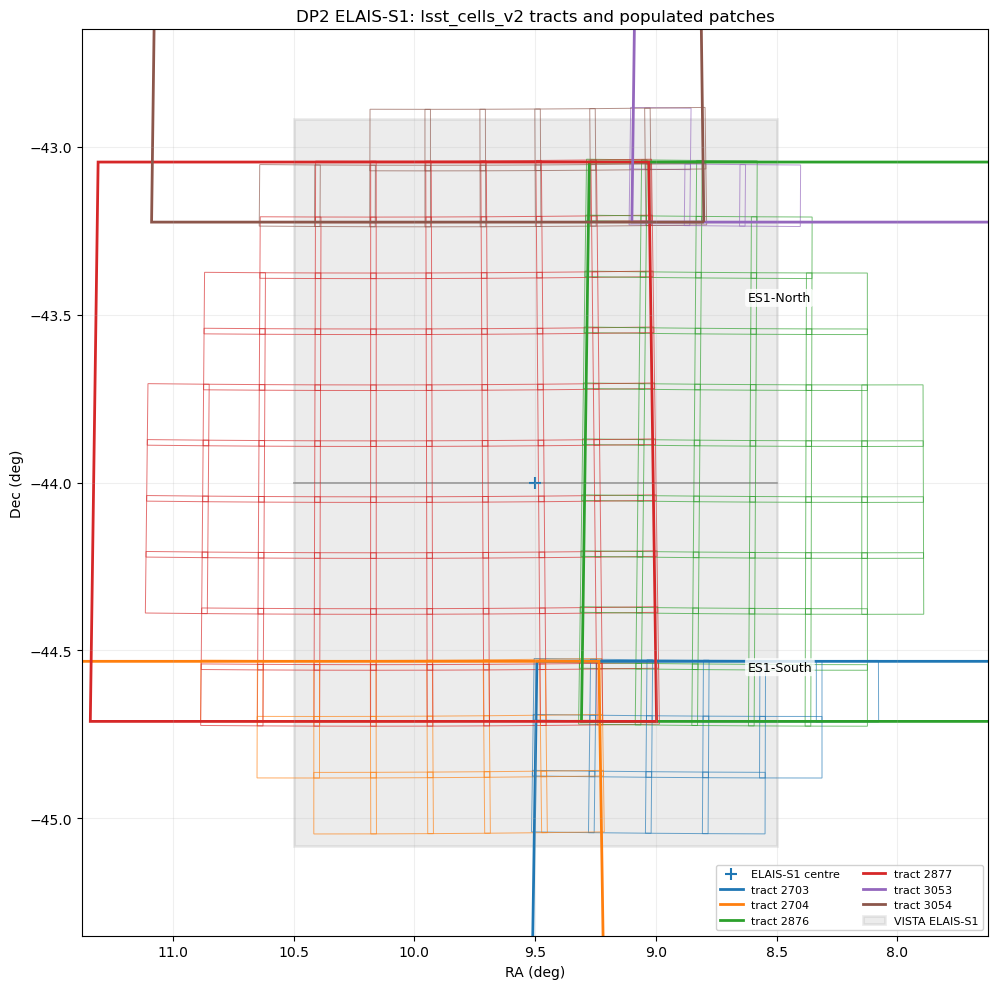

Saved: data/figures/DP2_ELAIS1_skymap_VISTA_coverage.png
Saved: data/figures/DP2_ELAIS1_skymap_VISTA_coverage.pdf


In [9]:
### Add the VISTA ELAIS-S1 coverage

from matplotlib.patches import Rectangle

# Approximate VISTA ELAIS-S1 footprint from the ES1-North/ES1-South coverage.
# RA: 00:34:00 -- 00:42:00  ->  8.5 -- 10.5 deg
# Dec: -45:05:00 -- -42:55:00
vista_ra_min = 8.5
vista_ra_max = 10.5
vista_dec_min = -(45 + 5 / 60)
vista_dec_max = -(42 + 55 / 60)

vista_width = vista_ra_max - vista_ra_min
vista_height = vista_dec_max - vista_dec_min

vista_footprint = Rectangle(
    (vista_ra_min, vista_dec_min),
    vista_width,
    vista_height,
    facecolor="gray",
    edgecolor="gray",
    linewidth=2.0,
    alpha=0.15,
    label="VISTA ELAIS-S1",
    zorder=0.5,
)

ax.add_patch(vista_footprint)

# Approximate division between ES1-North and ES1-South.
vista_dec_split = -44.0

ax.plot(
    [vista_ra_min, vista_ra_max],
    [vista_dec_split, vista_dec_split],
    color="gray",
    linewidth=1.2,
    alpha=0.8,
    zorder=0.6,
)

# Labels inside the VISTA footprint.
vista_ra_label = vista_ra_min + 0.12

ax.text(
    vista_ra_label,
    -43.45,
    "ES1-North",
    fontsize=9,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
    ),
)

ax.text(
    vista_ra_label,
    -44.55,
    "ES1-South",
    fontsize=9,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
    ),
)

# Update the legend to include the VISTA footprint.
ax.legend(
    loc="lower right",
    fontsize=8,
    framealpha=0.9,
    ncol=2,
)

# Save a version including the VISTA footprint.
vista_png = figure_dir / "DP2_ELAIS1_skymap_VISTA_coverage.png"
vista_pdf = figure_dir / "DP2_ELAIS1_skymap_VISTA_coverage.pdf"

fig.savefig(vista_png, dpi=200, bbox_inches="tight")
fig.savefig(vista_pdf, bbox_inches="tight")

display(fig)

print(f"Saved: {vista_png}")
print(f"Saved: {vista_pdf}")

### 9. Select and export a representative DP2 test patch
For the first local DP2 processing test, select a single patch in the VIDEO ES1-North region that has complete LSST (ugrizy) coverage and lies fully inside the VISTA footprint. Among the eligible patches, choose the one closest to the approximate centre of ES1-North. The patch polygon is then written to a small CSV file so that the corresponding VISTA exposures and reference-catalogue shards can be selected on CSD3 without requiring access to the RSP Butler.

In [10]:
# ============================================================
# Select one central DP2 patch inside VIDEO ES1-North
# and export its geometry for the CSD3 VIDEO selection
# ============================================================

import pandas as pd

required_bands = set("ugrizy")

# Approximate centre of VIDEO ES1-North.
# North extends from Dec=-44.0 to Dec=-42:55.
target_ra = 9.5
target_dec = 0.5 * (-44.0 + vista_dec_max)

candidates = []

for record in dp2_patch_records:

    tract = int(record.dataId["tract"])
    patch = int(record.dataId["patch"])

    bands = bands_by_patch[(tract, patch)]

    # Require complete DP2 ugrizy coverage.
    if not required_bands.issubset(bands):
        continue

    vertices = region_vertices_deg(record.region)

    ra_min = vertices[:, 0].min()
    ra_max = vertices[:, 0].max()
    dec_min = vertices[:, 1].min()
    dec_max = vertices[:, 1].max()

    # Require the complete patch to lie inside ES1-North.
    fully_inside_north = (
        ra_min >= vista_ra_min
        and ra_max <= vista_ra_max
        and dec_min >= -44.0
        and dec_max <= vista_dec_max
    )

    if not fully_inside_north:
        continue

    patch_ra = np.mean(vertices[:, 0])
    patch_dec = np.mean(vertices[:, 1])

    # Small-angle distance from the ES1-North centre.
    dra = (
        (patch_ra - target_ra)
        * np.cos(np.deg2rad(target_dec))
    )

    ddec = patch_dec - target_dec

    distance = np.hypot(dra, ddec)

    candidates.append(
        (
            distance,
            tract,
            patch,
            patch_ra,
            patch_dec,
            vertices,
            sorted(bands),
        )
    )


if not candidates:
    raise RuntimeError(
        "No complete ugrizy DP2 patch was found fully inside ES1-North."
    )


# Choose the patch nearest the centre of VIDEO ES1-North.
candidates.sort(key=lambda x: x[0])

(
    distance,
    test_tract,
    test_patch,
    patch_ra,
    patch_dec,
    patch_vertices,
    patch_bands,
) = candidates[0]


ra_min = patch_vertices[:, 0].min()
ra_max = patch_vertices[:, 0].max()
dec_min = patch_vertices[:, 1].min()
dec_max = patch_vertices[:, 1].max()


print("Selected DP2 test patch")
print("=======================")
print(f"tract       : {test_tract}")
print(f"patch       : {test_patch}")
print(f"bands       : {','.join(patch_bands)}")
print(
    f"centre      : RA={patch_ra:.6f}, "
    f"Dec={patch_dec:.6f}"
)
print(
    f"RA range    : {ra_min:.6f} -- {ra_max:.6f}"
)
print(
    f"Dec range   : {dec_min:.6f} -- {dec_max:.6f}"
)
print(
    f"offset from ES1-N centre: "
    f"{distance * 60:.2f} arcmin"
)

# Approximate physical angular size.
width_arcmin = (
    (ra_max - ra_min)
    * np.cos(np.deg2rad(patch_dec))
    * 60.0
)

height_arcmin = (
    (dec_max - dec_min)
    * 60.0
)

print(
    f"approx size : "
    f"{width_arcmin:.2f} x "
    f"{height_arcmin:.2f} arcmin"
)


# ------------------------------------------------------------
# Export the patch polygon.
# This tiny CSV is the only DP2 information needed on CSD3.
# ------------------------------------------------------------

patch_table = pd.DataFrame(
    {
        "tract": test_tract,
        "patch": test_patch,
        "vertex_order": np.arange(
            len(patch_vertices)
        ),
        "ra_deg": patch_vertices[:, 0],
        "dec_deg": patch_vertices[:, 1],
        "patch_ra_cen": patch_ra,
        "patch_dec_cen": patch_dec,
    }
)

patch_file = (
    output_dir
    / "DP2_ELAIS1_ES1N_test_patch.csv"
)

patch_table.to_csv(
    patch_file,
    index=False,
)

print()
print(f"Wrote: {patch_file}")

patch_table

Selected DP2 test patch
tract       : 2877
patch       : 77
bands       : g,i,r,u,y,z
centre      : RA=9.595381, Dec=-43.466106
RA range    : 9.468023 -- 9.722353
Dec range   : -43.558397 -- -43.373819
offset from ES1-N centre: 4.18 arcmin
approx size : 11.08 x 11.07 arcmin

Wrote: data/DP2_ELAIS1_ES1N_test_patch.csv


,tract,patch,vertex_order,ra_deg,dec_deg,patch_ra_cen,patch_dec_cen
0,2877,77,0,9.468023,-43.557129,9.595381,-43.466106
1,2877,77,1,9.720985,-43.558397,9.595381,-43.466106
2,2877,77,2,9.722353,-43.375079,9.595381,-43.466106
3,2877,77,3,9.470163,-43.373819,9.595381,-43.466106
